# List 4
## Author: Jan Pułtorak

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = None
if not torch.backends.mps.is_available():
    if not torch.backends.mps.is_built():
        print("MPS not available because the current PyTorch install was not built with MPS enabled.")
    else:
        print("MPS not available because the current MacOS version is not 12.3+ "
              "and/or you do not have an MPS-enabled device on this machine.")

else:
    print("MPS enabled")
    device = torch.device("mps")

transform = transforms.ToTensor()

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_subset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

MPS enabled


/Users/janek/dev/uwr/neural-networks/.venv/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Batch shape (X): torch.Size([128, 3, 32, 32])
Batch shape (Y): torch.Size([128])
image shape: torch.Size([3, 32, 32])
Min value: 0.0745
Max value: 0.8863


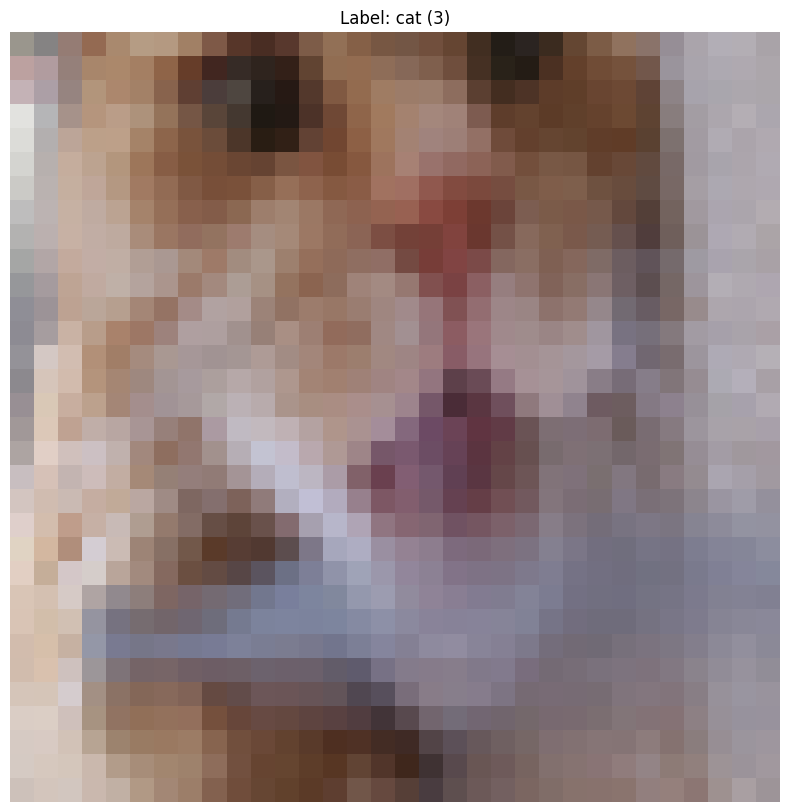

In [2]:
images, labels = next(iter(train_loader))

sample_image = images[0]
sample_label = labels[0]

print(f"Batch shape (X): {images.shape}")
print(f"Batch shape (Y): {labels.shape}")
print(f"image shape: {sample_image.shape}")
print(f"Min value: {sample_image.min().item():.4f}")
print(f"Max value: {sample_image.max().item():.4f}")


classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

image_to_plot = sample_image.permute(1, 2, 0).numpy()

plt.figure(figsize=(10, 10))
plt.imshow(image_to_plot)

label_name = classes[sample_label.item()]
plt.title(f"Label: {label_name} ({sample_label.item()})")
plt.axis('off')
plt.show()

## Starter code

In [3]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 32 * 3, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.net(x)

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_samples += x.size(0)

    return total_loss / total_samples, total_correct / total_samples

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_samples += x.size(0)

    return total_loss / total_samples, total_correct / total_samples


## Task 1

In [4]:
model_seq = nn.Sequential(
    nn.Flatten(),
    nn.Linear(32 * 32 * 3, 512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 10)
)

class CustomMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32 * 32 * 3, 512)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(512, 256)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        return self.fc3(x)

model_custom = CustomMLP()

In [5]:
print(model_custom)

trainable_params = sum(p.numel() for p in model_custom.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params}")

CustomMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3072, out_features=512, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=256, out_features=10, bias=True)
)
Trainable parameters: 1707274


### Explanations
1. **What torch.nn.Module represents**

    It is a base class for all neural network modules.

2. **Why PyTorch automatically tracks parameters**

    This mechanism allows methods like model.parameters() to recursively gather all weights across the network so they can be passed to an optimizer.

3. **When nn.Sequential is convenient**

    It is good for simple feed-forward models.

4. **When a custom nn.Module is preferable**

    It is necessary when the computation is complex, not just a simple chain.

## Task 2

Epoch 01/30 | Train Loss: 2.2196, Acc: 0.1887 | Val Loss: 2.1165, Acc: 0.2520
Epoch 02/30 | Train Loss: 2.0337, Acc: 0.2760 | Val Loss: 1.9833, Acc: 0.2968
Epoch 03/30 | Train Loss: 1.9403, Acc: 0.3083 | Val Loss: 1.9211, Acc: 0.3142
Epoch 04/30 | Train Loss: 1.8842, Acc: 0.3327 | Val Loss: 1.8672, Acc: 0.3438
Epoch 05/30 | Train Loss: 1.8434, Acc: 0.3478 | Val Loss: 1.8311, Acc: 0.3598
Epoch 06/30 | Train Loss: 1.8070, Acc: 0.3614 | Val Loss: 1.8060, Acc: 0.3540
Epoch 07/30 | Train Loss: 1.7745, Acc: 0.3727 | Val Loss: 1.7676, Acc: 0.3754
Epoch 08/30 | Train Loss: 1.7456, Acc: 0.3824 | Val Loss: 1.7498, Acc: 0.3790
Epoch 09/30 | Train Loss: 1.7184, Acc: 0.3900 | Val Loss: 1.7291, Acc: 0.3836
Epoch 10/30 | Train Loss: 1.6938, Acc: 0.3973 | Val Loss: 1.7054, Acc: 0.3938
Epoch 11/30 | Train Loss: 1.6736, Acc: 0.4067 | Val Loss: 1.6856, Acc: 0.3968
Epoch 12/30 | Train Loss: 1.6516, Acc: 0.4140 | Val Loss: 1.6505, Acc: 0.4152
Epoch 13/30 | Train Loss: 1.6345, Acc: 0.4216 | Val Loss: 1.6508

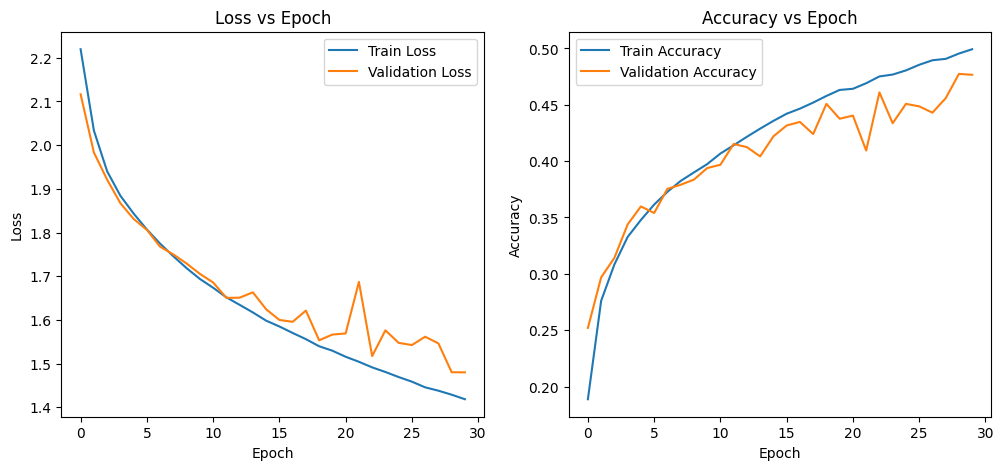

In [7]:
import torch.optim as optim

model = CustomMLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

train_losses, val_losses = [], []
train_accs, val_accs = [], []
epochs = 30

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1:02d}/{epochs} | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.title('Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

### Explanations

1. **Why we use mini-batches**

    Mini-batches provide a compromise between computational efficiency and gradient accuracy. Passing the entire dataset is usually too expensive, while passing one sample at a time is noisy. Mini-batches allow for fast, vectorizedoperations while providing a accurate estimate of the gradient.

2. **What model.train() and model.eval() do**

    These methods toggle the internal state of specific layers within the network that behave differently during training vs. inference. For example, Dropout layers are enabled during train() but disabled during eval().

3. **Why gradients are disabled during validation (@torch.no_grad())**

    During validation, we only want to measure the model's performance and we do not update its weights.

4. **Why optimizer.zero_grad() is necessary**

    By design, PyTorch accumulates gradients on subsequent backward passes. Not zeroing the grad would result in incorrect weight updates pointing in wrong directions.


## Task 3

In [8]:
import pandas as pd

optimizer_configs = {
    'SGD': {'optim_class': optim.SGD, 'kwargs': {'lr': 0.1}},
    'SGD+Momentum': {'optim_class': optim.SGD, 'kwargs': {'lr': 0.01, 'momentum': 0.9}},
    'SGD+Nesterov': {'optim_class': optim.SGD, 'kwargs': {'lr': 0.01, 'momentum': 0.9, 'nesterov': True}},
    'RMSprop': {'optim_class': optim.RMSprop, 'kwargs': {'lr': 0.001}},
    'Adam': {'optim_class': optim.Adam, 'kwargs': {'lr': 0.001}}
}

epochs = 30
results = {}

print("----- Optimizer Comparison ----")

for opt_name, config in optimizer_configs.items():
    print(f"\n--- Training with {opt_name} ---")

    model = CustomMLP().to(device)
    criterion = nn.CrossEntropyLoss()

    optimizer = config['optim_class'](model.parameters(), **config['kwargs'])

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

    print(f"Final Val Acc: {val_acc:.4f} | Final Train Acc: {train_acc:.4f}")
    results[opt_name] = history

----- Optimizer Comparison ----

--- Training with SGD ---
Final Val Acc: 0.5120 | Final Train Acc: 0.6491

--- Training with SGD+Momentum ---
Final Val Acc: 0.5444 | Final Train Acc: 0.6644

--- Training with SGD+Nesterov ---
Final Val Acc: 0.5304 | Final Train Acc: 0.7006

--- Training with RMSprop ---
Final Val Acc: 0.5002 | Final Train Acc: 0.6076

--- Training with Adam ---
Final Val Acc: 0.5294 | Final Train Acc: 0.6501


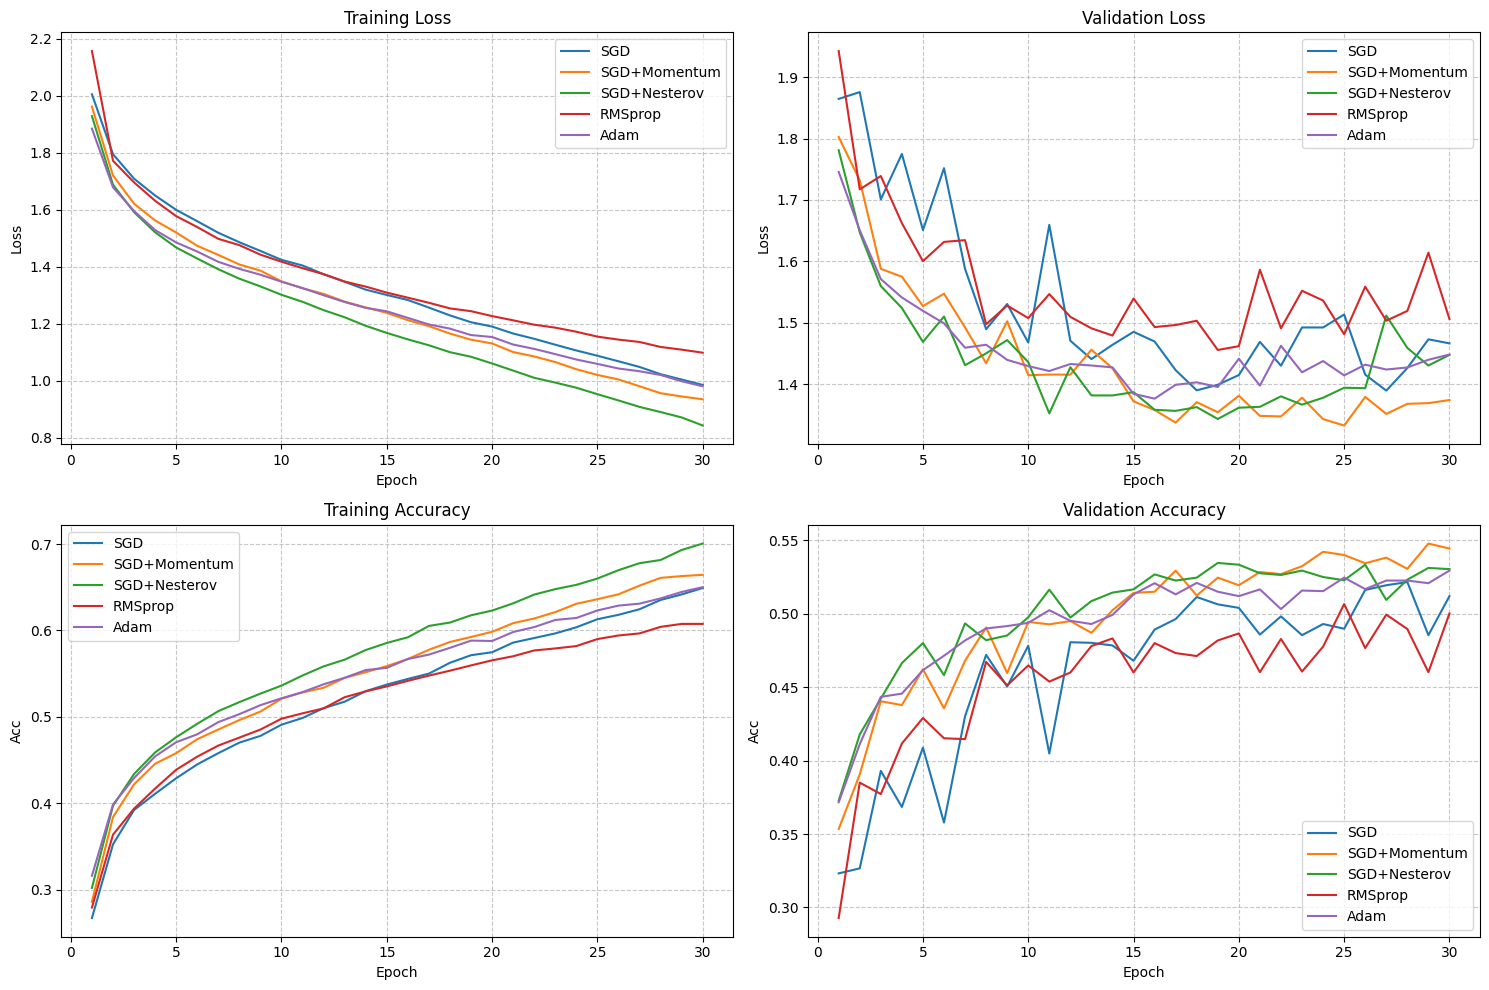

,Optimizer,Learning Rate,Final Train Loss,Final Val Loss,Final Train Acc,Final Val Acc
0,SGD,0.100,0.984580,1.466569,0.649133,0.5120
1,SGD+Momentum,0.010,0.934223,1.374299,0.664378,0.5444
2,SGD+Nesterov,0.010,0.842150,1.447795,0.700556,0.5304
3,RMSprop,0.001,1.097699,1.506168,0.607578,0.5002
4,Adam,0.001,0.979769,1.448338,0.650089,0.5294


In [9]:
plt.figure(figsize=(15, 10))
metrics = ['train_loss', 'val_loss', 'train_acc', 'val_acc']
titles = ['Training Loss', 'Validation Loss', 'Training Accuracy', 'Validation Accuracy']

for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    for opt_name, history in results.items():
        plt.plot(range(1, epochs + 1), history[metric], label=opt_name)
    plt.title(titles[i-1])
    plt.xlabel('Epoch')
    plt.ylabel(metric.split('_')[1].capitalize())
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

table_data = []
for opt_name, config in optimizer_configs.items():
    history = results[opt_name]
    lr = config['kwargs']['lr']
    table_data.append({
        'Optimizer': opt_name,
        'Learning Rate': lr,
        'Final Train Loss': history['train_loss'][-1],
        'Final Val Loss': history['val_loss'][-1],
        'Final Train Acc': history['train_acc'][-1],
        'Final Val Acc': history['val_acc'][-1]
    })

df_results = pd.DataFrame(table_data)
df_results

### Explanation
1. Fastest convergence - SGD + Nesterov
2. Best validation accuracy - SGD + Momentum, though it is similar for Nestrov and Adam as well
3. The only noticable difference is that Adam had much smoother convergence than any other method.
4. Momentum and Nestrov had boh smoother and faster convergence, as well as higher validation accuracy.